<a href="https://colab.research.google.com/github/aniketkumar112sonu-ui/fraud-detection-risk-engine/blob/main/notebook_03_fraud_detection_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fraud Detection & Risk Scoring System

## Problem Statement

The goal of this project is to build a machine learning system that identifies
fraudulent financial transactions from legitimate transactions.

The dataset is highly imbalanced, so the project focuses on detecting fraud
using appropriate evaluation metrics such as Precision, Recall, F1-score,
ROC-AUC and PR-AUC rather than relying on accuracy alone.

The final system will also generate a fraud probability and risk score for
each transaction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score)

In [3]:
df = pd.read_csv("/content/paysim dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


BASIC CLEANING

In [4]:
# Remove missing values
df = df.dropna().copy()

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

df = df.sort_values("step").reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape after cleaning: (6362620, 11)
Missing values: 0
Duplicate rows: 0


##  Time-Based Train / Validation / Test Split


In [5]:
# Sort by time
df = df.sort_values("step").reset_index(drop=True)

# Find split points
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

# Chronological split
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["step"].min(), "→", train_df["step"].max())
print("Validation:", val_df["step"].min(), "→", val_df["step"].max())
print("Test:", test_df["step"].min(), "→", test_df["step"].max())

Train shape: (4453834, 11)
Validation shape: (954393, 11)
Test shape: (954393, 11)

Time ranges:
Train: 1 → 323
Validation: 323 → 378
Test: 378 → 743


## Feature Engineering

Creating transaction-level features to capture abnormal balance behavior.

In [6]:
def create_basic_features(data):
    data = data.copy()

    # Time features
    data["hour"] = data["step"] % 24
    data["day"] = data["step"] // 24
    data["is_night"] = ((data["hour"] >= 0) & (data["hour"] < 6)).astype(int)

    # Balance changes
    data["orig_balance_change"] = (
        data["oldbalanceOrg"] - data["newbalanceOrig"]
    )

    data["dest_balance_change"] = (
        data["newbalanceDest"] - data["oldbalanceDest"]
    )

    # Balance inconsistency
    data["orig_error"] = (
        data["amount"] - data["orig_balance_change"]
    )

    return data


train_df = create_basic_features(train_df)
val_df = create_basic_features(val_df)
test_df = create_basic_features(test_df)

### Account Transaction Frequency

In [7]:
# Calculate frequencies only from training data
orig_freq = train_df["nameOrig"].value_counts()
dest_freq = train_df["nameDest"].value_counts()

# Apply training-based frequencies to all datasets
train_df["orig_transaction_count"] = train_df["nameOrig"].map(orig_freq).fillna(0)
val_df["orig_transaction_count"] = val_df["nameOrig"].map(orig_freq).fillna(0)
test_df["orig_transaction_count"] = test_df["nameOrig"].map(orig_freq).fillna(0)

train_df["dest_transaction_count"] = train_df["nameDest"].map(dest_freq).fillna(0)
val_df["dest_transaction_count"] = val_df["nameDest"].map(dest_freq).fillna(0)
test_df["dest_transaction_count"] = test_df["nameDest"].map(dest_freq).fillna(0)

### Amount-Based Features

In [8]:
def create_amount_features(data):
    data = data.copy()

    # Log transformation of transaction amount
    data["amount_log"] = np.log1p(data["amount"])

    # Transaction amount relative to sender's balance
    data["amount_to_orig_balance"] = (
        data["amount"] / (data["oldbalanceOrg"] + 1)
    )

    # Transaction amount relative to receiver's balance
    data["amount_to_dest_balance"] = (
        data["amount"] / (data["oldbalanceDest"] + 1)
    )

    # Indicators for zero balances
    data["orig_balance_zero"] = (
        data["oldbalanceOrg"] == 0
    ).astype(int)

    data["dest_balance_zero"] = (
        data["oldbalanceDest"] == 0
    ).astype(int)

    return data


train_df = create_amount_features(train_df)
val_df = create_amount_features(val_df)
test_df = create_amount_features(test_df)

### Prepare Features for Modeling

In [9]:
# Separate target
X_train = train_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_train = train_df["isFraud"]

X_val = val_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_val = val_df["isFraud"]

X_test = test_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_test = test_df["isFraud"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (4453834, 21)
X_val: (954393, 21)
X_test: (954393, 21)

Features:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'hour', 'day', 'is_night', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'orig_transaction_count', 'dest_transaction_count', 'amount_log', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_zero', 'dest_balance_zero']


##  Preprocessing

In [10]:
# Identify feature types
categorical_features = ["type"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['type']

Numerical features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'hour', 'day', 'is_night', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'orig_transaction_count', 'dest_transaction_count', 'amount_log', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_zero', 'dest_balance_zero']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numerical_features), ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Class Imbalance

In [12]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
isFraud
0    4450191
1       3643
Name: count, dtype: int64

Training class percentage:
isFraud
0    99.918205
1     0.081795
Name: proportion, dtype: float64


## A Model Training

### A.1 Logistic Regression Baseline

Logistic Regression is used as an interpretable baseline model for binary fraud classification.

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=100
    ))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [15]:
# Predict fraud probabilities
y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

Precision: 0.026921576277799453
Recall: 0.9822064056939501
F1-score: 0.05240672173170037
ROC-AUC: 0.9980626226187006
PR-AUC: 0.5790226620261132


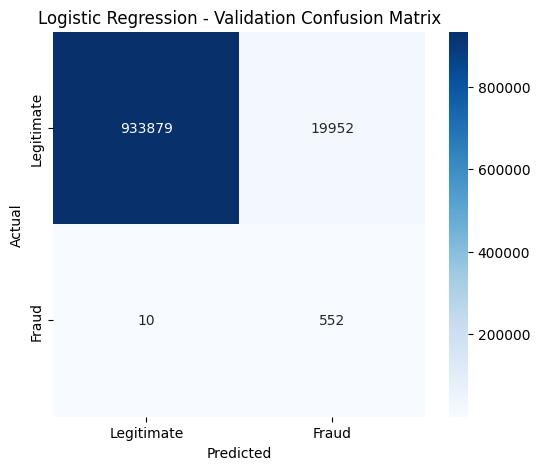

In [16]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### A.2 Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
# Random Forest validation probabilities
rf_val_proba = rf_pipeline.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
rf_val_pred = (rf_val_proba >= 0.5).astype(int)

print("Precision:", precision_score(y_val, rf_val_pred))
print("Recall:", recall_score(y_val, rf_val_pred))
print("F1-score:", f1_score(y_val, rf_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, rf_val_proba))
print("PR-AUC:", average_precision_score(y_val, rf_val_proba))

Precision: 1.0
Recall: 0.99644128113879
F1-score: 0.9982174688057041
ROC-AUC: 1.0
PR-AUC: 1.0


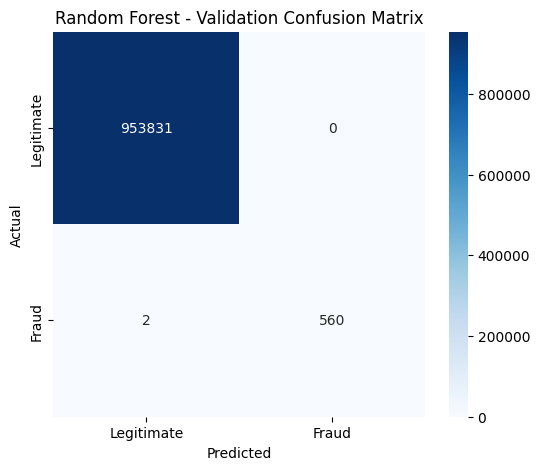

In [19]:
cm = confusion_matrix(y_val, rf_val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###  Model Comparison

In [20]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_val, y_val_pred),
        precision_score(y_val, rf_val_pred)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred),
        recall_score(y_val, rf_val_pred)
    ],
    "F1": [
        f1_score(y_val, y_val_pred),
        f1_score(y_val, rf_val_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_proba),
        roc_auc_score(y_val, rf_val_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_proba),
        average_precision_score(y_val, rf_val_proba)
    ]
})

model_results

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.026922,0.982206,0.052407,0.998063,0.579023
1,Random Forest,1.000000,0.996441,0.998217,1.000000,1.000000


## A.3 HistGradientBoosting
### HistGradientBoosting needs dense numerical input,
### so we'll create a separate preprocessing setup.

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features)
    ]
)

hgb_pipeline = Pipeline([
    ("preprocessor", hgb_preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    ))
])

hgb_pipeline.fit(X_train, y_train)

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [22]:
# Predict fraud probabilities
hgb_val_proba = hgb_pipeline.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
hgb_val_pred = (hgb_val_proba >= 0.5).astype(int)

print("Precision:", precision_score(y_val, hgb_val_pred))
print("Recall:", recall_score(y_val, hgb_val_pred))
print("F1-score:", f1_score(y_val, hgb_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, hgb_val_proba))
print("PR-AUC:", average_precision_score(y_val, hgb_val_proba))

Precision: 0.9982174688057041
Recall: 0.99644128113879
F1-score: 0.9973285841495992
ROC-AUC: 0.9964408390183463
PR-AUC: 0.9945181942111614


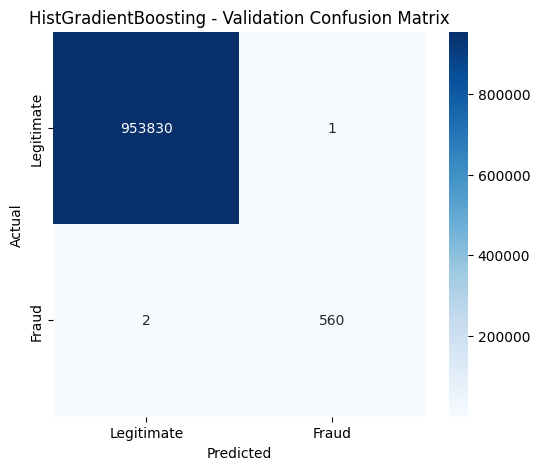

In [23]:
cm = confusion_matrix(y_val, hgb_val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("HistGradientBoosting - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparsion

In [24]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Precision": [
        precision_score(y_val, y_val_pred),
        precision_score(y_val, rf_val_pred),
        precision_score(y_val, hgb_val_pred)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred),
        recall_score(y_val, rf_val_pred),
        recall_score(y_val, hgb_val_pred)
    ],
    "F1": [
        f1_score(y_val, y_val_pred),
        f1_score(y_val, rf_val_pred),
        f1_score(y_val, hgb_val_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_proba),
        roc_auc_score(y_val, rf_val_proba),
        roc_auc_score(y_val, hgb_val_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_proba),
        average_precision_score(y_val, rf_val_proba),
        average_precision_score(y_val, hgb_val_proba)
    ]
})

model_results

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.026922,0.982206,0.052407,0.998063,0.579023
1,Random Forest,1.000000,0.996441,0.998217,1.000000,1.000000
2,HistGradientBoosting,0.998217,0.996441,0.997329,0.996441,0.994518


## B. Threshold Optimization

### B.1 Finding the Optimal Fraud Classification Threshold

In [25]:
from sklearn.metrics import precision_recall_curve

# Precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(
    y_val,
    rf_val_proba
)

# Calculate F1-score for each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Find threshold with maximum F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best validation F1:", f1_scores[best_idx])
print("Precision at best threshold:", precision[best_idx])
print("Recall at best threshold:", recall[best_idx])

Best threshold: 0.45
Best validation F1: 0.99999999995
Precision at best threshold: 1.0
Recall at best threshold: 1.0


## C Final Test Evaluation

The test set is used only once for the final evaluation of the selected model
and threshold.

In [26]:
# Apply the selected threshold to the untouched test set
rf_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_test_pred = (rf_test_proba >= best_threshold).astype(int)

print("Final Test Results")
print("------------------")
print("Precision:", precision_score(y_test, rf_test_pred))
print("Recall:", recall_score(y_test, rf_test_pred))
print("F1-score:", f1_score(y_test, rf_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_test_proba))
print("PR-AUC:", average_precision_score(y_test, rf_test_proba))

Final Test Results
------------------
Precision: 1.0
Recall: 0.9995009980039921
F1-score: 0.9997504367357125
ROC-AUC: 1.0
PR-AUC: 1.0


### C.1 Final Test Confusion Matrix

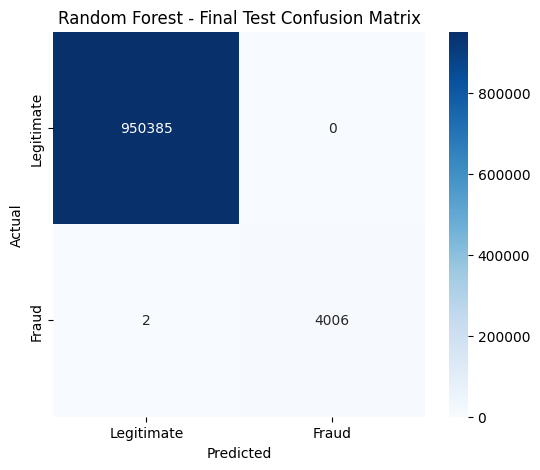

In [28]:
cm = confusion_matrix(y_test, rf_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## D. Feature Importance

Analyzing which features contribute most to the Random Forest's fraud predictions.

In [29]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance
importances = rf_pipeline.named_steps["model"].feature_importances_

# Create importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
12,num__orig_error,0.223148
10,num__orig_balance_change,0.211362
16,num__amount_to_orig_balance,0.191868
3,num__newbalanceOrig,0.117472
2,num__oldbalanceOrg,0.075201
17,num__amount_to_dest_balance,0.033778
23,cat__type_PAYMENT,0.026639
15,num__amount_log,0.024430
1,num__amount,0.019856
11,num__dest_balance_change,0.019650


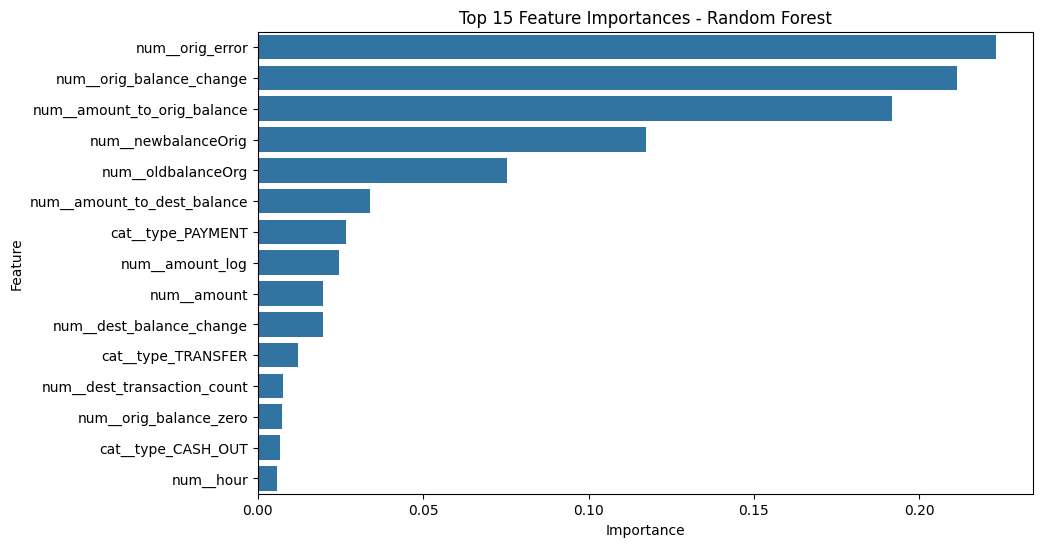

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## E. Risk Scoring

Converting fraud probability into a 0–100 risk score.

In [31]:
# Convert fraud probability to a 0–100 risk score
risk_score = rf_test_proba * 100

risk_score[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [32]:
def risk_category(score):
    if score < 30:
        return "Low Risk"
    elif score < 70:
        return "Medium Risk"
    else:
        return "High Risk"


risk_category_values = np.array([
    risk_category(score) for score in risk_score
])

risk_category_values[:10]

array(['Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk'],
      dtype='<U11')

In [33]:
final_results = X_test.copy()

final_results["fraud_probability"] = rf_test_proba
final_results["risk_score"] = risk_score
final_results["risk_category"] = risk_category_values
final_results["actual_fraud"] = y_test.values

final_results[
    [
        "fraud_probability",
        "risk_score",
        "risk_category",
        "actual_fraud"
    ]
].head(10)

,fraud_probability,risk_score,risk_category,actual_fraud
5408227,0.0,0.0,Low Risk,0
5408228,0.0,0.0,Low Risk,0
5408229,0.0,0.0,Low Risk,0
5408230,0.0,0.0,Low Risk,0
5408231,0.0,0.0,Low Risk,0
5408232,0.0,0.0,Low Risk,0
5408233,0.0,0.0,Low Risk,0
5408234,0.0,0.0,Low Risk,0
5408235,0.0,0.0,Low Risk,0
5408236,0.0,0.0,Low Risk,0


In [34]:
print("Risk Category Distribution:")
print(final_results["risk_category"].value_counts())

print("\nRisk Category Percentage:")
print(
    final_results["risk_category"]
    .value_counts(normalize=True) * 100
)

Risk Category Distribution:
risk_category
Low Risk       950385
High Risk        4006
Medium Risk         2
Name: count, dtype: int64

Risk Category Percentage:
risk_category
Low Risk       99.580047
High Risk       0.419743
Medium Risk     0.000210
Name: proportion, dtype: float64


## F. Final Model Summary

Random Forest was selected as the final model based on its strong performance
on the validation set.

The classification threshold was optimized using the validation set to
balance precision and recall. A threshold of 0.45 was selected.

The final model was then evaluated on the unseen test set using:
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

The model also generates a fraud probability and converts it into a
0–100 risk score for easier interpretation.

In [36]:
print("FINAL MODEL PERFORMANCE")
print("=" * 30)

print(f"Precision : {precision_score(y_test, rf_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, rf_test_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, rf_test_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_test_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, rf_test_proba):.4f}")

print(f"\nDecision Threshold: {best_threshold:.2f}")

FINAL MODEL PERFORMANCE
Precision : 1.0000
Recall    : 0.9995
F1-score  : 0.9998
ROC-AUC   : 1.0000
PR-AUC    : 1.0000

Decision Threshold: 0.45


## G. Conclusion

This project developed a machine learning-based fraud detection and risk
scoring system for financial transactions.

The workflow included:
- Data cleaning and preprocessing
- Time-based train, validation, and test splitting
- Feature engineering
- Handling severe class imbalance using class weights
- Comparison of Logistic Regression, Random Forest, and
  HistGradientBoosting
- Threshold optimization using the validation set
- Final evaluation on unseen test data
- Fraud probability and 0–100 risk score generation

Random Forest was selected as the final model because it achieved strong
precision, recall, F1-score, ROC-AUC, and PR-AUC performance.

The final system can classify transactions as legitimate or fraudulent and
assign a risk level of Low, Medium, or High.

## H. Limitations & Future Improvements

### Limitations
- PaySim is a synthetic dataset, so real-world fraud behavior may differ.
- The dataset is highly imbalanced.
- Model performance may decrease on unseen real-world transaction patterns.
- Risk thresholds would need to be adjusted according to business requirements.

### Future Improvements
- Test the system on real-world transaction data.
- Explore advanced boosting models such as XGBoost or LightGBM.
- Use cost-sensitive learning based on the financial impact of fraud.
- Develop a real-time fraud detection API.
- Add continuous model monitoring and retraining.